# Khảo Sát Tham Số Bộ Trọng Số Chỉ Số Ùn Tắc TCI (Traffic Congestion Index)
**Thành viên thực hiện:** TV1 (Leader)  
**Mục đích:** Thực hiện Parameter Sweep cho bộ trọng số (w1: Diện tích chiếm dụng, w2: Độ suy giảm vận tốc, w3: Tải trọng PCU) để chứng minh tính hiệu quả của mô hình kết hợp đa đặc trưng.

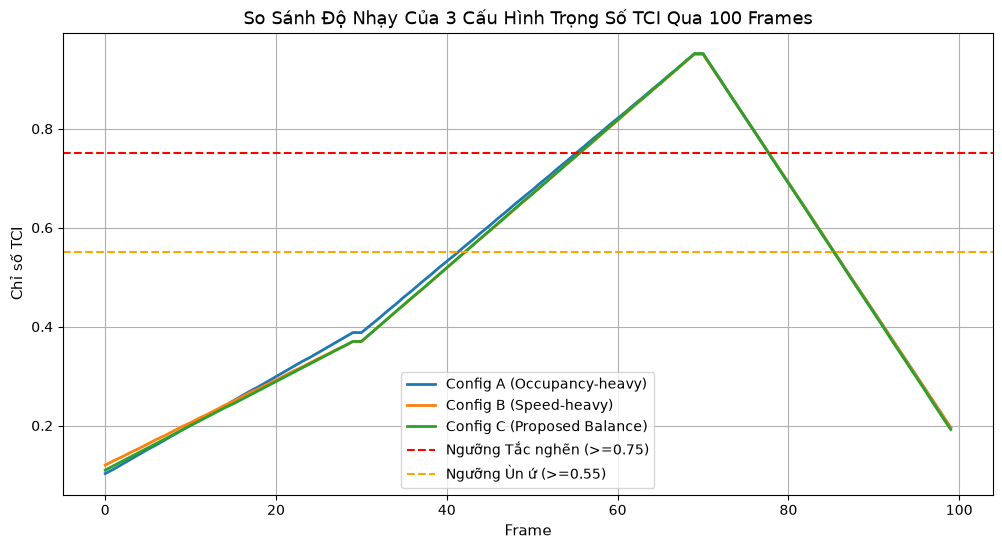

In [692]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
from modules.congestion_evaluator import TrafficCongestionEvaluator

# 1. Định nghĩa 3 kịch bản tham số (Parameter Sweep)
configs = {
    "Config A (Occupancy-heavy)": TrafficCongestionEvaluator(w_occ=0.8, w_spd=0.1, w_pcu=0.1),
    "Config B (Speed-heavy)":     TrafficCongestionEvaluator(w_occ=0.1, w_spd=0.8, w_pcu=0.1),
    "Config C (Proposed Balance)": TrafficCongestionEvaluator(w_occ=0.4, w_spd=0.4, w_pcu=0.2)
}

# 2. Tạo chuỗi dữ liệu giả lập kịch bản ùn tắc biến thiên (từ thông thoáng -> tắc nghẽn -> giải tỏa)
frames = 100
occupancy_sim = np.concatenate([np.linspace(0.1, 0.4, 30), np.linspace(0.4, 0.95, 40), np.linspace(0.95, 0.2, 30)])
speed_sim     = np.concatenate([np.linspace(35, 25, 30), np.linspace(25, 2, 40), np.linspace(2, 32, 30)])
pcu_sim       = np.concatenate([np.linspace(5, 15, 30), np.linspace(15, 48, 40), np.linspace(48, 8, 30)])

# 3. Tính toán và vẽ đồ thị đối sánh
plt.figure(figsize=(12, 6))
for name, evaluator in configs.items():
    tci_vals = []
    for occ, spd, pcu in zip(occupancy_sim, speed_sim, pcu_sim):
        res = evaluator.compute_tci(occ, spd, pcu)
        tci_vals.append(res['instant_tci'])
    plt.plot(tci_vals, label=name, linewidth=2)

plt.axhline(y=0.75, color='r', linestyle='--', label='Ngưỡng Tắc nghẽn (>=0.75)')
plt.axhline(y=0.55, color='orange', linestyle='--', label='Ngưỡng Ùn ứ (>=0.55)')
plt.title("So Sánh Độ Nhạy Của 3 Cấu Hình Trọng Số TCI Qua 100 Frames", fontsize=13)
plt.xlabel("Frame", fontsize=11)
plt.ylabel("Chỉ số TCI", fontsize=11)
plt.legend()
plt.grid(True)
plt.show()